# Parse: is the DEG floor of inert proteins a matter of statistical power?

In OP3, two wells of an identical treatment gave almost no DEGs (median 0), whereas in Parse the
receptor-negative proteins gave a median of 389 DEGs against PBS. The two analyses differ in power:
Parse has 12 donors and thousands of cells per well, OP3 six plates and a few hundred cells per well.

This notebook repeats the Parse DEG counts with OP3-like power (6 donors, 100 or 300 cells per well)
and adds the comparison that matches the OP3 test exactly: **two PBS wells against each other**
(identical treatment, different wells, different first-round barcodes).

Comparisons (pseudobulk DESeq2, design `~ donor + condition`, thresholds of the paper):

| name | what | OP3 analogue |
|---|---|---|
| `PBS_vs_PBS` | one PBS well against another (15 pairs) | DMSO well vs DMSO well |
| `inert_vs_inert` | one receptor-negative protein against another (10 pairs) | — |
| `inert_vs_PBS` | receptor-negative protein against the pooled PBS wells (as in the paper) | — |

How to read it:

- `PBS_vs_PBS` large with 12 donors: the per-well signature (barcode, position) repeats across donors
  and creates DEGs on its own; OP3 differs because its wells are not linked to a barcode.
- `PBS_vs_PBS` near 0 but `inert_vs_PBS` large: the floor comes from the protein wells (reagent or a
  weak real effect), not from the well itself.
- Everything near 0 with 6 donors and 100–300 cells: the Parse floor is mainly power, and the OP3
  result is not evidence against it.

In [2]:
import os, re, itertools, warnings
import numpy as np
import pandas as pd
import h5py
import scipy.sparse as sp
import matplotlib.pyplot as plt

PARSE_FILE = "data/parse10m/20260203_Parse_10M_PBMC_cytokines.h5ad"   # edit if the file has another name
CACHE_DIR = "data/parse10m/cache"
RESULTS_DIR = "results/donorvar_parse"
os.makedirs(RESULTS_DIR, exist_ok=True)
PWR_DIR = os.path.join(CACHE_DIR, "deg_power")
os.makedirs(PWR_DIR, exist_ok=True)
F_PB = os.path.join(PWR_DIR, "pb_bins.npz")
F_META = os.path.join(PWR_DIR, "pb_bins_meta.csv")
F_DEG = os.path.join(RESULTS_DIR, "deg_power_check_cpm10.csv")   # one row per DESeq2 run (resumable)
FIG_OUT = os.path.join(RESULTS_DIR, "Fig_deg_power_check.png")

INERT = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO", "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
STRICT_INERT = ["TPO", "Megalin", "PSPN", "EPO", "EGF"]
PBS_NAME = "PBS"
IFN_GROUP = ["Donor1", "Donor3", "Donor4", "Donor10"]
CELL_TYPES = ["B", "CD4 T", "CD8 T", "NK", "CD14 Mono", "CD16 Mono"]
TEST_CELL_TYPES = ["CD4 T", "CD14 Mono", "B"]   # closest to OP3's T, myeloid and B cells

# column names in obs; None = detect automatically (printed below, check them)
COLS = dict(donor=None, cytokine=None, well=None, cell_type=None)
CT_MAP = None             # dict fine label -> main type; None = rule-based merge (printed below)

CAPS = [100, 300]         # cells per well in the power-matched settings (OP3: ~85 B/myeloid, ~320 T)
N_DONOR_SUBSETS = 2       # random 6-donor subsets
MIN_CELLS_DEG = 50        # min cells per pseudobulk when cells are not capped (as in the paper)
MIN_DONORS = 4
MIN_CPM = 10              # genes tested: CPM >= 10 in pooled PBS (as in the original DEG analysis)
DEG_PADJ, DEG_LFC = 0.05, 0.25
N_CPUS = 8
SEED = 0
OP3_SAME_TREATMENT_MEDIAN = 0     # OP3 result: DEGs between two wells of one treatment
PAPER_STRICT_VS_PBS = 389         # Parse, paper: receptor-negative proteins vs PBS

## 1. Find the counts and the obs columns

In [3]:
H5 = h5py.File(PARSE_FILE, "r")

# counts: raw/X, else layers/counts, else X; must be CSR with integer values
for path in ["raw/X", "layers/counts", "X"]:
    if path in H5:
        g = H5[path]
        if isinstance(g, h5py.Group) and g.attrs.get("encoding-type", "csr_matrix") == "csr_matrix":
            sample = g["data"][:2000]
            if np.allclose(sample, np.round(sample)):
                COUNTS_PATH = path
                break
else:
    raise ValueError("no CSR matrix with integer counts found in raw/X, layers/counts or X")
MAT = H5[COUNTS_PATH]
INDPTR = MAT["indptr"][:]
N_OBS, N_VARS = (int(v) for v in MAT.attrs["shape"])
var_grp = H5["raw/var"] if COUNTS_PATH == "raw/X" else H5["var"]
GENES = np.array([x.decode() if isinstance(x, bytes) else str(x) for x in var_grp[var_grp.attrs["_index"]][:]])
assert len(GENES) == N_VARS
print(f"counts in {COUNTS_PATH}: {N_OBS:,} cells x {N_VARS:,} genes")

def read_cat(name):
    # (codes, categories) of an obs column; works for categorical and plain string columns
    obj = H5["obs"][name]
    dec = lambda arr: np.array([x.decode() if isinstance(x, bytes) else str(x) for x in arr])
    if isinstance(obj, h5py.Group):
        return obj["codes"][:].astype(np.int64), dec(obj["categories"][:])
    if "__categories" in H5["obs"] and name in H5["obs"]["__categories"]:
        return obj[:].astype(np.int64), dec(H5["obs"]["__categories"][name][:])
    cats, codes = np.unique(dec(obj[:]), return_inverse=True)
    return codes.astype(np.int64), cats

def cat_columns():
    # obs columns stored as categoricals (cheap to inspect)
    out = {}
    for name in H5["obs"].attrs.get("column-order", list(H5["obs"].keys())):
        obj = H5["obs"][name]
        if isinstance(obj, h5py.Group) and "categories" in obj:
            cats = obj["categories"][:]
            out[name] = np.array([x.decode() if isinstance(x, bytes) else str(x) for x in cats])
        elif "__categories" in H5["obs"] and name in H5["obs"]["__categories"]:
            cats = H5["obs"]["__categories"][name][:]
            out[name] = np.array([x.decode() if isinstance(x, bytes) else str(x) for x in cats])
    return out

CATS = cat_columns()
print("categorical obs columns:", {k: len(v) for k, v in CATS.items()})

def frac(cats, pattern):
    return np.mean([bool(re.search(pattern, c)) for c in cats]) if len(cats) else 0

if COLS["donor"] is None:
    COLS["donor"] = max(CATS, key=lambda k: frac(CATS[k], r"(?i)^donor[ _-]?\d+$"))
if COLS["cytokine"] is None:
    COLS["cytokine"] = max(CATS, key=lambda k: (PBS_NAME in CATS[k]) * sum(x in CATS[k] for x in INERT))
if COLS["cell_type"] is None:
    COLS["cell_type"] = max(CATS, key=lambda k: frac(CATS[k], r"CD14|CD16|CD4|CD8|NK") * (len(CATS[k]) < 200))

CODES = {r: read_cat(COLS[r]) for r in ["donor", "cytokine", "cell_type"]}

if COLS["well"] is None:
    # well-like columns (A1..H12); the sample well is the one with one well per cytokine and donor
    cands = [k for k, v in CATS.items() if frac(v, r"^[A-H](0?[1-9]|1[0-2])$") > 0.9 and len(v) >= 6]
    assert cands, "no well-like obs column found; set COLS['well'] by hand"
    cyt_codes, cyt_cats = CODES["cytokine"]
    don_codes = CODES["donor"][0]
    probe = np.flatnonzero(cyt_cats != PBS_NAME)[:20]
    best, best_score = None, np.inf
    rng0 = np.random.default_rng(0)
    idx = rng0.choice(N_OBS, size=min(N_OBS, 500_000), replace=False)
    for k in cands:
        wc, _ = read_cat(k)
        df = pd.DataFrame({"c": cyt_codes[idx], "d": don_codes[idx], "w": wc[idx]})
        score = df[df.c.isin(probe)].groupby(["c", "d"])["w"].nunique().median()
        if score < best_score:
            best, best_score = k, score
    COLS["well"] = best
CODES["well"] = read_cat(COLS["well"])
print("columns used:", COLS)
for r in ["donor", "cytokine", "cell_type"]:
    print(r, "->", list(CODES[r][1][:15]), "..." if len(CODES[r][1]) > 15 else "")

counts in X: 9,697,974 cells x 40,352 genes
categorical obs columns: {'sample': 1092, 'species': 1, 'bc1_well': 96, 'bc2_well': 192, 'bc3_well': 192, 'donor': 12, 'cytokine': 91, 'treatment': 2, 'cell_type': 18}
columns used: {'donor': 'donor', 'cytokine': 'cytokine', 'well': 'bc1_well', 'cell_type': 'cell_type'}
donor -> [np.str_('Donor1'), np.str_('Donor2'), np.str_('Donor3'), np.str_('Donor4'), np.str_('Donor5'), np.str_('Donor6'), np.str_('Donor7'), np.str_('Donor8'), np.str_('Donor9'), np.str_('Donor10'), np.str_('Donor11'), np.str_('Donor12')] 
cytokine -> [np.str_('4-1BBL'), np.str_('ADSF'), np.str_('APRIL'), np.str_('BAFF'), np.str_('C5a'), np.str_('CD27L'), np.str_('CD30L'), np.str_('CD40L'), np.str_('CT-1'), np.str_('Decorin'), np.str_('EGF'), np.str_('EPO'), np.str_('FGF-beta'), np.str_('FLT3L'), np.str_('FasL')] ...
cell_type -> [np.str_('B Intermediate/Memory'), np.str_('B Naive'), np.str_('CD4 Memory'), np.str_('CD4 Naive'), np.str_('CD8 Memory'), np.str_('CD8 Naive'), np

In [4]:
# merge fine cell types into the six main types (as in the paper); check this table
def main_type(label):
    s = label.replace("_", " ")
    if re.match(r"(?i)^CD4", s): return "CD4 T"
    if re.match(r"(?i)^CD8", s): return "CD8 T"
    if re.match(r"(?i)^B( |$)", s): return "B"
    if re.match(r"(?i)^CD14", s): return "CD14 Mono"
    if re.match(r"(?i)^CD16", s): return "CD16 Mono"
    if re.match(r"(?i)^NK$", s): return "NK"
    return None

ct_codes, ct_cats = CODES["cell_type"]
if CT_MAP is None:
    CT_MAP = {c: main_type(c) for c in ct_cats}
print(pd.Series(CT_MAP, name="main type").to_frame())

cyt_codes, cyt_cats = CODES["cytokine"]
don_codes, don_cats = CODES["donor"]
well_codes, well_cats = CODES["well"]
missing = [x for x in STRICT_INERT + [PBS_NAME] if x not in cyt_cats]
assert not missing, f"not found in the cytokine column: {missing}"

ct_main = np.array([CT_MAP.get(c) for c in ct_cats], dtype=object)
want_cyt = np.isin(cyt_cats, STRICT_INERT + [PBS_NAME])
want_ct = np.isin(ct_main, TEST_CELL_TYPES)
sel_pos = np.flatnonzero(want_cyt[cyt_codes] & want_ct[ct_codes])
print(f"{len(sel_pos):,} cells selected")

sel = pd.DataFrame({"donor": don_cats[don_codes[sel_pos]],
                    "cyt": cyt_cats[cyt_codes[sel_pos]],
                    "well": well_cats[well_codes[sel_pos]],
                    "ct": ct_main[ct_codes[sel_pos]]}, index=sel_pos)
# a condition is a protein, or a single PBS well
sel["cond"] = np.where(sel["cyt"] == PBS_NAME, PBS_NAME + "_" + sel["well"], sel["cyt"])
print("PBS wells per donor:", sel[sel.cyt == PBS_NAME].groupby("donor")["well"].nunique().to_dict())
print("wells per protein and donor (should be 1):",
      sel[sel.cyt != PBS_NAME].groupby(["cyt", "donor"])["well"].nunique().max())
print(sel.groupby(["ct", "cyt"]).size().unstack().round(-2))

                       main type
B Intermediate/Memory          B
B Naive                        B
CD4 Memory                 CD4 T
CD4 Naive                  CD4 T
CD8 Memory                 CD8 T
CD8 Naive                  CD8 T
CD14 Mono              CD14 Mono
CD16 Mono              CD16 Mono
HSPC                         NaN
ILC                          NaN
MAIT                         NaN
NK                            NK
NK CD56bright                NaN
NKT                          NaN
Plasmablast                  NaN
Treg                         NaN
cDC                          NaN
pDC                          NaN
754,375 cells selected
PBS wells per donor: {'Donor1': 6, 'Donor10': 6, 'Donor11': 6, 'Donor12': 6, 'Donor2': 6, 'Donor3': 6, 'Donor4': 6, 'Donor5': 6, 'Donor6': 6, 'Donor7': 6, 'Donor8': 6, 'Donor9': 6}
wells per protein and donor (should be 1): 1
cyt          EGF    EPO  Megalin     PBS   PSPN    TPO
ct                                                    
B          103

## 2. Pseudobulks in cell-rank bins

Cells of each donor × condition × cell type are put in random order and summed in bins
(first 100, next 200, the rest). Capping at 100 or 300 cells is then a sum of bins, so one pass
over the counts serves every setting.

In [5]:
rng = np.random.default_rng(SEED)
KEYS = ["donor", "cond", "ct"]
EDGES = [0] + CAPS + [np.inf]
sel["u"] = rng.random(len(sel))
sel = sel.sort_values("u")
sel["rank"] = sel.groupby(KEYS).cumcount()
sel["bin"] = np.searchsorted(CAPS, sel["rank"].to_numpy(), side="right")
g = sel.groupby(KEYS + ["bin"], sort=True)
gid = g.ngroup().to_numpy()
meta = g.size().rename("n").reset_index()
n_total = sel.groupby(KEYS).size().rename("n_total")
meta = meta.join(n_total, on=KEYS)
print(f"{len(meta):,} binned pseudobulks")

def aggregate(cell_pos, gids, n_groups, chunk=50_000):
    # sum raw counts of selected cells into groups, reading only spans that contain selected cells
    order = np.argsort(cell_pos)
    pos, gids = cell_pos[order], gids[order]
    out = np.zeros((n_groups, N_VARS), dtype=np.float64)
    for i0 in range(0, len(pos), chunk):
        i1 = min(i0 + chunk, len(pos))
        start, end = pos[i0], pos[i1 - 1] + 1
        lo, hi = INDPTR[start], INDPTR[end]
        X = sp.csr_matrix((MAT["data"][lo:hi], MAT["indices"][lo:hi], INDPTR[start:end + 1] - lo),
                          shape=(end - start, N_VARS))
        sub = X[pos[i0:i1] - start]
        M = sp.csr_matrix((np.ones(i1 - i0), (gids[i0:i1], np.arange(i1 - i0))), shape=(n_groups, i1 - i0))
        out += (M @ sub).toarray()
        if (i0 // chunk) % 20 == 0:
            print(f"  {i1:,} / {len(pos):,} cells", flush=True)
    return out

if os.path.exists(F_PB) and os.path.exists(F_META) and len(pd.read_csv(F_META)) == len(meta):
    PB = np.load(F_PB)["pb"]
    print("loaded cached pseudobulks")
else:
    PB = aggregate(sel.index.to_numpy(), gid, len(meta))
    np.savez_compressed(F_PB, pb=PB.astype(np.float32))
    meta.to_csv(F_META, index=False)
print(PB.shape)

1,175 binned pseudobulks
loaded cached pseudobulks
(1175, 40352)


In [6]:
def pseudobulk(ct, cond, donors, cap):
    # counts (donors x genes) of one condition; cap = None for all cells.
    # cond = 'PBS_pooled' sums the PBS wells (each capped). Returns counts and the donors kept.
    conds = sorted(c for c in meta.cond.unique() if c.startswith(PBS_NAME + "_")) if cond == "PBS_pooled" else [cond]
    need = MIN_CELLS_DEG if cap is None else cap
    max_bin = len(CAPS) if cap is None else CAPS.index(cap)
    rows, kept = [], []
    for d in donors:
        tot, ok = np.zeros(N_VARS), True
        for c in conds:
            m = meta[(meta.ct == ct) & (meta.cond == c) & (meta.donor == d)]
            if m.empty or m.n_total.iloc[0] < need:
                ok = False
                break
            tot += PB[m.index[m.bin <= max_bin]].sum(0)
        if ok:
            rows.append(tot); kept.append(d)
    return np.array(rows), kept

def expressed_mask(ct):
    # same gene filter as the original DEG analysis: CPM in pooled PBS (all cells, 12 donors) >= MIN_CPM
    pbs, _ = pseudobulk(ct, "PBS_pooled", sorted(meta.donor.unique()), None)
    tot = pbs.sum(0)
    return tot / tot.sum() * 1e6 >= MIN_CPM

EXPR_MASK = {ct: expressed_mask(ct) for ct in TEST_CELL_TYPES}
print({ct: int(m.sum()) for ct, m in EXPR_MASK.items()}, "genes tested per cell type")

{'CD4 T': 9211, 'CD14 Mono': 8707, 'B': 9401} genes tested per cell type


## 3. DESeq2 runs

In [7]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
warnings.filterwarnings("ignore")

def n_degs(ct, cond_a, cond_b, donors, cap):
    A, da = pseudobulk(ct, cond_a, donors, cap)
    B, db = pseudobulk(ct, cond_b, donors, cap)
    common = [d for d in da if d in db]
    if len(common) < MIN_DONORS:
        return None, len(common)
    A = A[[da.index(d) for d in common]]
    B = B[[db.index(d) for d in common]]
    counts = np.vstack([A, B]).round().astype(np.int64)
    keep = EXPR_MASK[ct]
    names = [f"a{i}" for i in range(len(common))] + [f"b{i}" for i in range(len(common))]
    dcode = {d: f"d{i}" for i, d in enumerate(common)}
    md_ = pd.DataFrame({"donor": [dcode[d] for d in common] * 2,
                        "condition": ["a"] * len(common) + ["b"] * len(common)}, index=names)
    dds = DeseqDataSet(counts=pd.DataFrame(counts[:, keep], index=names, columns=GENES[keep]),
                       metadata=md_, design="~donor + condition", quiet=True, n_cpus=N_CPUS)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "b", "a"], quiet=True, n_cpus=N_CPUS)
    st.summary()
    r = st.results_df
    return int(((r.padj < DEG_PADJ) & (r.log2FoldChange.abs() > DEG_LFC)).sum()), len(common)

DONORS = sorted(meta.donor.unique(), key=lambda s: int(re.sub(r"\D", "", s) or 0))
rs = np.random.default_rng(SEED + 1)
SETTINGS = [("12 donors", DONORS, None), ("12 donors", DONORS, CAPS[-1]), ("12 donors", DONORS, CAPS[0])]
for k in range(N_DONOR_SUBSETS):
    sub = sorted(rs.choice(DONORS, size=6, replace=False).tolist())
    SETTINGS += [(f"6 donors #{k + 1}", sub, None), (f"6 donors #{k + 1}", sub, CAPS[-1]),
                 (f"6 donors #{k + 1}", sub, CAPS[0])]

PBS_WELLS = sorted(c for c in meta.cond.unique() if c.startswith(PBS_NAME + "_"))
COMPARISONS = ([("PBS_vs_PBS", a, b) for a, b in itertools.combinations(PBS_WELLS, 2)] +
               [("inert_vs_PBS", "PBS_pooled", p) for p in STRICT_INERT] +
               [("inert_vs_inert", a, b) for a, b in itertools.combinations(STRICT_INERT, 2)])

# most informative runs first: full power, then matched power
jobs = [(s, ct, c) for s in SETTINGS for ct in TEST_CELL_TYPES for c in COMPARISONS]
done = pd.read_csv(F_DEG) if os.path.exists(F_DEG) else pd.DataFrame(columns=["key"])
done_keys = set(done["key"])
print(len(jobs), "DESeq2 runs,", len(done_keys), "already done")

for (sname, donors, cap), ct, (kind, ca, cb) in jobs:
    key = f"{sname}|{cap}|{ct}|{kind}|{ca}|{cb}"
    if key in done_keys:
        continue
    n, nd = n_degs(ct, ca, cb, donors, cap)
    row = dict(key=key, setting=sname, n_donors_set=len(donors), cap="all" if cap is None else cap,
               ct=ct, kind=kind, cond_a=ca, cond_b=cb, n_donors_used=nd, n_deg=n)
    pd.DataFrame([row]).to_csv(F_DEG, mode="a", header=not os.path.exists(F_DEG), index=False)
    done_keys.add(key)

810 DESeq2 runs, 810 already done


## 4. Results

In [8]:
R = pd.read_csv(F_DEG).dropna(subset=["n_deg"])
R["power"] = np.where(R.n_donors_set == 12, "12 donors", "6 donors") + ", " + R.cap.astype(str) + " cells"
ORDER = [f"12 donors, all cells", f"12 donors, {CAPS[-1]} cells", f"12 donors, {CAPS[0]} cells",
         f"6 donors, all cells", f"6 donors, {CAPS[-1]} cells", f"6 donors, {CAPS[0]} cells"]
SUM = (R.groupby(["kind", "power"])["n_deg"].median().unstack("power")
       .reindex(columns=[o for o in ORDER if o in R.power.unique()]))
print("Median DEGs over pairs, cell types and donor subsets")
SUM

Median DEGs over pairs, cell types and donor subsets


power,"12 donors, all cells","12 donors, 300 cells","12 donors, 100 cells","6 donors, all cells","6 donors, 300 cells","6 donors, 100 cells"
kind,,,,,,
PBS_vs_PBS,690.0,214.0,44.0,507.5,43.5,9.5
inert_vs_PBS,399.0,202.0,67.0,321.0,51.0,13.5
inert_vs_inert,596.5,159.0,37.0,357.0,35.5,11.0


In [9]:
print("By cell type (median DEGs)")
R.groupby(["ct", "kind", "power"])["n_deg"].median().unstack("power").reindex(
    columns=[o for o in ORDER if o in R.power.unique()])

By cell type (median DEGs)


power                     12 donors, all cells  12 donors, 300 cells  \
ct        kind                                                         
B         PBS_vs_PBS                     570.0                 116.0   
          inert_vs_PBS                   399.0                 164.0   
          inert_vs_inert                 455.0                 144.0   
CD14 Mono PBS_vs_PBS                     691.0                 351.0   
          inert_vs_PBS                   472.0                 559.0   
          inert_vs_inert                 624.0                 337.0   
CD4 T     PBS_vs_PBS                     708.0                 142.0   
          inert_vs_PBS                   387.0                 195.0   
          inert_vs_inert                 681.0                 150.0   

power                     12 donors, 100 cells  6 donors, all cells  \
ct        kind                                                        
B         PBS_vs_PBS                      29.0                157.0   
          inert_vs_PBS                    67.0                136.0   
          inert_vs_inert                  32.5                 86.0   
CD14 Mono PBS_vs_PBS                     110.0                520.5   
          inert_vs_PBS                   184.0                556.0   
          inert_vs_inert                 107.5                370.5   
CD4 T     PBS_vs_PBS                      33.0                691.0   
          inert_vs_PBS                    62.0                392.0   
          inert_vs_inert                  34.5                503.0   

power                     6 donors, 300 cells  6 donors, 100 cells  
ct        kind                                                      
B         PBS_vs_PBS                     26.0                  8.0  
          inert_vs_PBS                   20.5                 13.0  
          inert_vs_inert                 26.0                  9.0  
CD14 Mono PBS_vs_PBS                     95.5                 24.0  
          inert_vs_PBS                  166.5                 38.0  
          inert_vs_inert                 81.0                 22.5  
CD4 T     PBS_vs_PBS                     35.5                  6.0  
          inert_vs_PBS                   50.5                  8.5  
          inert_vs_inert                 34.0                  6.0

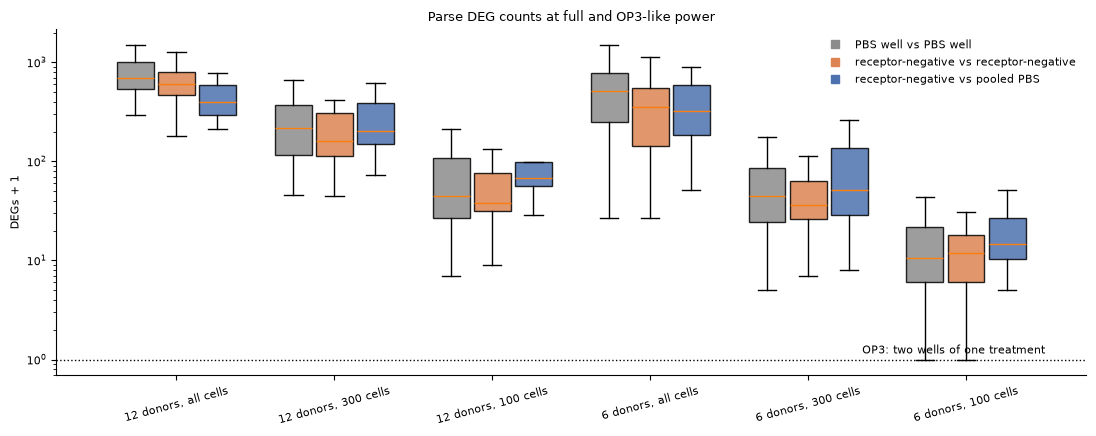

In [10]:
KIND_COL = {"PBS_vs_PBS": "#8C8C8C", "inert_vs_inert": "#DD8452", "inert_vs_PBS": "#4C72B0"}
KIND_LAB = {"PBS_vs_PBS": "PBS well vs PBS well", "inert_vs_inert": "receptor-negative vs receptor-negative",
            "inert_vs_PBS": "receptor-negative vs pooled PBS"}
powers = [o for o in ORDER if o in R.power.unique()]
fig, ax = plt.subplots(figsize=(11, 4.4))
w = 0.26
for k, kind in enumerate(KIND_COL):
    data = [R[(R.kind == kind) & (R.power == p)]["n_deg"].to_numpy() + 1 for p in powers]
    x = np.arange(len(powers)) + (k - 1) * w
    bp = ax.boxplot([d if len(d) else [np.nan] for d in data], positions=x, widths=w * 0.9,
                    patch_artist=True, showfliers=False)
    for b in bp["boxes"]:
        b.set_facecolor(KIND_COL[kind]); b.set_alpha(0.85)
    ax.plot([], [], "s", color=KIND_COL[kind], label=KIND_LAB[kind])
ax.axhline(OP3_SAME_TREATMENT_MEDIAN + 1, ls=":", color="k", lw=1)
ax.text(len(powers) - 0.5, (OP3_SAME_TREATMENT_MEDIAN + 1) * 1.15, "OP3: two wells of one treatment", ha="right", fontsize=8)
ax.set_yscale("log"); ax.set_xticks(range(len(powers))); ax.set_xticklabels(powers, rotation=15)
ax.set_ylabel("DEGs + 1"); ax.legend(fontsize=8, frameon=False, loc="upper right")
ax.set_title("Parse DEG counts at full and OP3-like power")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG_OUT, dpi=200); plt.show()

In [11]:
def med(kind, power):
    v = R[(R.kind == kind) & (R.power == power)]["n_deg"]
    return f"{v.median():.0f}" if len(v) else "n/a"
full, low = ORDER[0], ORDER[-1]
print(f"Full power ({full}): PBS well vs PBS well {med('PBS_vs_PBS', full)}, "
      f"receptor-negative vs receptor-negative {med('inert_vs_inert', full)}, "
      f"receptor-negative vs pooled PBS {med('inert_vs_PBS', full)}.")
print(f"OP3-like power ({low}): PBS well vs PBS well {med('PBS_vs_PBS', low)}, "
      f"receptor-negative vs receptor-negative {med('inert_vs_inert', low)}, "
      f"receptor-negative vs pooled PBS {med('inert_vs_PBS', low)}.")

Full power (12 donors, all cells): PBS well vs PBS well 690, receptor-negative vs receptor-negative 596, receptor-negative vs pooled PBS 399.
OP3-like power (6 donors, 100 cells): PBS well vs PBS well 10, receptor-negative vs receptor-negative 11, receptor-negative vs pooled PBS 14.


## 5. Does the number of DEGs depend on the distance between wells?

In [12]:
# PBS wells (row H): Mantel test over all 720 permutations of the six well labels,
# and the correlation after removing each well in turn. Main setting: 12 donors, all cells.
num = lambda s: int(re.search(r"(\d+)$", s).group(1))
P = R[R.kind == "PBS_vs_PBS"].copy()
for (st_, cap_, ct), h in P.groupby(["setting", "cap", "ct"]):
    pw = f"{st_}, {cap_} cells"
    wells = sorted(set(h.cond_a) | set(h.cond_b), key=num)
    pairs = list(itertools.combinations(wells, 2))
    deg = {frozenset((a, b)): n for a, b, n in zip(h.cond_a, h.cond_b, h.n_deg)}
    if any(frozenset(p) not in deg for p in pairs):
        continue
    y = np.array([deg[frozenset(p)] for p in pairs])
    stat = lambda lab: np.corrcoef([abs(num(lab[a]) - num(lab[b])) for a, b in pairs], y)[0, 1]
    obs = stat({w: w for w in wells})
    null = np.array([stat(dict(zip(wells, perm))) for perm in itertools.permutations(wells)])
    d = np.array([abs(num(a) - num(b)) for a, b in pairs])
    loo = [np.corrcoef(d[[w not in p for p in pairs]], y[[w not in p for p in pairs]])[0, 1] for w in wells]
    print(f"{pw:26s} {ct:10s} r={obs:+.2f} Mantel p={np.mean(null >= obs):.3f}  "
          f"adjacent={np.median(y[d == 1]):.0f} far={np.median(y[d >= 4]):.0f}  "
          f"r without one well: {min(loo):.2f} to {max(loo):.2f}")

12 donors, 100 cells       B          r=+0.70 Mantel p=0.017  adjacent=11 far=69  r without one well: 0.66 to 0.89
12 donors, 100 cells       CD14 Mono  r=+0.69 Mantel p=0.019  adjacent=66 far=237  r without one well: 0.62 to 0.90
12 donors, 100 cells       CD4 T      r=+0.68 Mantel p=0.022  adjacent=24 far=75  r without one well: 0.64 to 0.89
12 donors, 300 cells       B          r=+0.60 Mantel p=0.039  adjacent=105 far=261  r without one well: 0.53 to 0.86
12 donors, 300 cells       CD14 Mono  r=+0.67 Mantel p=0.025  adjacent=214 far=616  r without one well: 0.59 to 0.93
12 donors, 300 cells       CD4 T      r=+0.67 Mantel p=0.028  adjacent=99 far=371  r without one well: 0.58 to 0.90
12 donors, all cells       B          r=+0.69 Mantel p=0.025  adjacent=456 far=945  r without one well: 0.58 to 0.93
12 donors, all cells       CD14 Mono  r=+0.73 Mantel p=0.019  adjacent=534 far=1040  r without one well: 0.65 to 0.94
12 donors, all cells       CD4 T      r=+0.70 Mantel p=0.022  adjacen

In [13]:
# receptor-negative proteins (interior wells): Mantel test on plate distance, 120 permutations
wmap = sel[sel.cyt != PBS_NAME].groupby("cyt")["well"].first().to_dict()
print("wells:", wmap)
xy = {p: ("ABCDEFGH".index(w[0]), int(w[1:])) for p, w in wmap.items()}
dist = lambda a, b: np.hypot(xy[a][0] - xy[b][0], xy[a][1] - xy[b][1])
prots = sorted(wmap)
pairs = list(itertools.combinations(prots, 2))
for (st_, cap_, ct), h in R[R.kind == "inert_vs_inert"].groupby(["setting", "cap", "ct"]):
    pw = f"{st_}, {cap_} cells"
    deg = {frozenset((a, b)): n for a, b, n in zip(h.cond_a, h.cond_b, h.n_deg)}
    if any(frozenset(p) not in deg for p in pairs):
        continue
    y = np.array([deg[frozenset(p)] for p in pairs])
    stat = lambda lab: np.corrcoef([dist(lab[a], lab[b]) for a, b in pairs], y)[0, 1]
    obs = stat({p: p for p in prots})
    null = np.array([stat(dict(zip(prots, perm))) for perm in itertools.permutations(prots)])
    print(f"{pw:26s} {ct:10s} r={obs:+.2f} Mantel p={np.mean(null >= obs):.3f}")

wells: {'EGF': 'E9', 'EPO': 'F10', 'Megalin': 'E4', 'PSPN': 'F3', 'TPO': 'G1'}
12 donors, 100 cells       B          r=-0.32 Mantel p=0.925
12 donors, 100 cells       CD14 Mono  r=-0.39 Mantel p=0.917
12 donors, 100 cells       CD4 T      r=-0.45 Mantel p=0.975
12 donors, 300 cells       B          r=-0.17 Mantel p=0.692
12 donors, 300 cells       CD14 Mono  r=-0.48 Mantel p=0.975
12 donors, 300 cells       CD4 T      r=-0.37 Mantel p=0.908
12 donors, all cells       B          r=-0.35 Mantel p=0.933
12 donors, all cells       CD14 Mono  r=-0.44 Mantel p=0.967
12 donors, all cells       CD4 T      r=-0.36 Mantel p=0.925
6 donors #1, 100 cells     B          r=-0.23 Mantel p=0.783
6 donors #1, 100 cells     CD14 Mono  r=+0.00 Mantel p=0.542
6 donors #1, 100 cells     CD4 T      r=-0.48 Mantel p=0.975
6 donors #1, 300 cells     B          r=-0.14 Mantel p=0.692
6 donors #1, 300 cells     CD14 Mono  r=-0.48 Mantel p=0.975
6 donors #1, 300 cells     CD4 T      r=-0.34 Mantel p=0.892
6 dono

## 6. Figures 4E and S3 for the paper

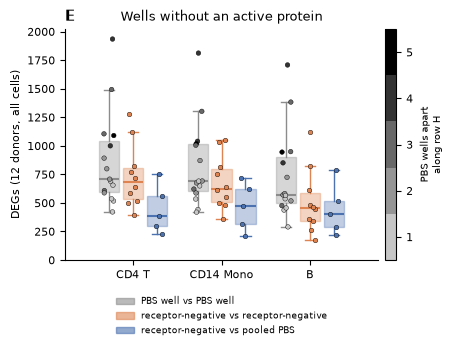

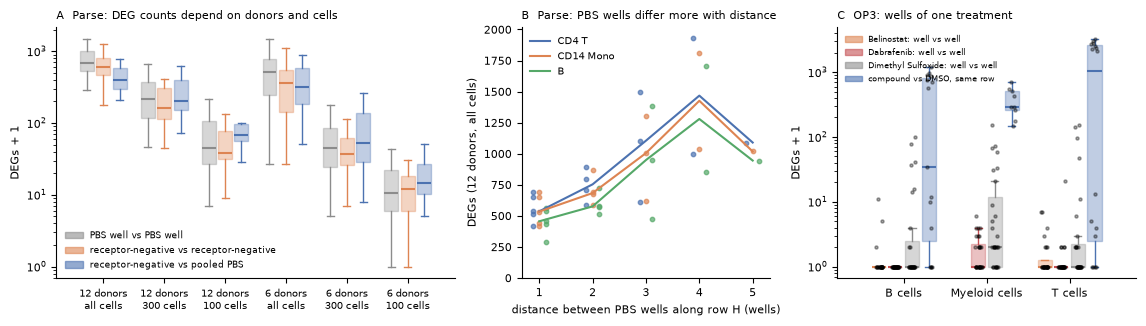

In [14]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

OP3_DEG_FILE = "cache/op3_posctrl/deg_ctrl_wells.csv"   # written by op3_positive_controls.ipynb
GREY, ORANGE, BLUE, RED = "#8C8C8C", "#DD8452", "#4C72B0", "#C44E52"
KINDS = [("PBS_vs_PBS", GREY, "PBS well vs PBS well"),
         ("inert_vs_inert", ORANGE, "receptor-negative vs receptor-negative"),
         ("inert_vs_PBS", BLUE, "receptor-negative vs pooled PBS")]
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.dpi": 300, "savefig.bbox": "tight"})
num = lambda s: int(re.search(r"(\d+)$", s).group(1))
jit = np.random.default_rng(0)

def box(ax, data, x, col, w):
    ax.boxplot([data if len(data) else [np.nan]], positions=[x], widths=w, patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=col, alpha=0.35, edgecolor=col), medianprops=dict(color=col, lw=1.5),
               whiskerprops=dict(color=col), capprops=dict(color=col))

D = R.copy()
D["dist"] = np.nan
pbs = D.kind == "PBS_vs_PBS"
D.loc[pbs, "dist"] = (D.loc[pbs, "cond_a"].map(num) - D.loc[pbs, "cond_b"].map(num)).abs()
FULL = D[(D.n_donors_set == 12) & (D.cap.astype(str) == "all")]

# ---------- Figure 4E: wells without an active protein ----------
fig, ax = plt.subplots(figsize=(4.3, 3.0))
w = 0.27
for j, ct in enumerate(TEST_CELL_TYPES):
    for k, (kind, col, _) in enumerate(KINDS):
        d = FULL[(FULL.ct == ct) & (FULL.kind == kind)]
        x = j + (k - 1) * w
        box(ax, d.n_deg.to_numpy(), x, col, w * 0.85)
        xs = x + jit.uniform(-w * 0.22, w * 0.22, len(d))
        if kind == "PBS_vs_PBS":
            sc = ax.scatter(xs, d.n_deg, c=d.dist, cmap="Greys", vmin=-1, vmax=5, s=11,
                            edgecolor="k", linewidth=0.3, zorder=3)
        else:
            ax.scatter(xs, d.n_deg, color=col, s=11, edgecolor="k", linewidth=0.3, zorder=3)
ax.set_xticks(range(len(TEST_CELL_TYPES)))
ax.set_xticklabels(TEST_CELL_TYPES)
ax.set_ylabel("DEGs (12 donors, all cells)")
ax.set_ylim(0, None)
cb = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, boundaries=np.arange(0.5, 5.6), ticks=[1, 2, 3, 4, 5])
cb.set_label("PBS wells apart\nalong row H", fontsize=7)
ax.legend([Patch(color=c, alpha=0.6) for _, c, _ in KINDS], [l for _, _, l in KINDS],
          fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
#ax.set_title("E", loc="left", fontweight="bold")
ax.set_title("E", loc="left", fontweight="bold", fontsize=11)
ax.set_title("Wells without an active protein", loc="center")
fig.savefig(os.path.join(RESULTS_DIR, "Fig4E_identical_wells.png"))
fig.savefig(os.path.join(RESULTS_DIR, "Fig4E_identical_wells.pdf"))
plt.show()

# ---------- Figure S3 ----------
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.3), gridspec_kw={"width_ratios": [1.6, 1, 1.2]})

# (A) power
D["power"] = np.where(D.n_donors_set == 12, "12 donors", "6 donors") + "\n" + D.cap.astype(str) + " cells"
order = [f"{n} donors\n{c} cells" for n in (12, 6) for c in ("all", 300, 100)]
for j, p in enumerate(order):
    for k, (kind, col, _) in enumerate(KINDS):
        box(ax[0], D[(D.power == p) & (D.kind == kind)].n_deg.to_numpy() + 1, j + (k - 1) * w, col, w * 0.85)
ax[0].set_yscale("log")
ax[0].set_xticks(range(len(order)))
ax[0].set_xticklabels(order, fontsize=7)
ax[0].set_ylabel("DEGs + 1")
ax[0].legend([Patch(color=c, alpha=0.6) for _, c, _ in KINDS], [l for _, _, l in KINDS],
             fontsize=6.5, frameon=False, loc="lower left")
ax[0].set_title("A  Parse: DEG counts depend on donors and cells", loc="left", fontsize=8)

# (B) distance along row H
CT_COL = dict(zip(TEST_CELL_TYPES, ["#4C72B0", "#DD8452", "#55A868"]))
P = FULL[FULL.kind == "PBS_vs_PBS"]
for k, ct in enumerate(TEST_CELL_TYPES):
    q = P[P.ct == ct]
    ax[1].scatter(q.dist + (k - 1) * 0.12, q.n_deg, s=10, color=CT_COL[ct], alpha=0.7)
    m = q.groupby("dist").n_deg.median()
    ax[1].plot(m.index, m.values, color=CT_COL[ct], label=ct)
ax[1].set_xticks(range(1, 6))
ax[1].set_xlabel("distance between PBS wells along row H (wells)")
ax[1].set_ylabel("DEGs (12 donors, all cells)")
ax[1].set_ylim(0, None)
ax[1].legend(fontsize=7, frameon=False)
ax[1].set_title("B  Parse: PBS wells differ more with distance", loc="left", fontsize=8)

# (C) OP3: wells of one treatment
if os.path.exists(OP3_DEG_FILE):
    O = pd.read_csv(OP3_DEG_FILE)
    conds = list(dict.fromkeys(O[O.kind == "same_treatment"].cond))
    dmso = [c for c in conds if re.search("(?i)sulfoxide|dmso", c)][0]
    conds = [c for c in conds if c != dmso] + [dmso]
    ccol = dict(zip(conds, [ORANGE, RED, GREY]))
    cts = sorted(O.ct.unique())
    groups = [(("same_treatment", c), ccol[c], f"{c}: well vs well") for c in conds] + \
             [(("vs_DMSO", None), BLUE, "compound vs DMSO, same row")]
    w3 = 0.8 / len(groups)
    for j, ct in enumerate(cts):
        for k, ((kind, c), col, _) in enumerate(groups):
            q = O[(O.ct == ct) & (O.kind == kind) & ((O.cond == c) if c else True)]
            x = j + (k - (len(groups) - 1) / 2) * w3
            box(ax[2], q.n_deg.to_numpy() + 1, x, col, w3 * 0.85)
            ax[2].scatter(x + jit.uniform(-w3 * 0.2, w3 * 0.2, len(q)), q.n_deg + 1, s=5, color="k", alpha=0.35, zorder=3)
    ax[2].set_yscale("log")
    ax[2].set_xticks(range(len(cts)))
    ax[2].set_xticklabels(cts)
    ax[2].set_ylabel("DEGs + 1")
    ax[2].legend([Patch(color=c, alpha=0.6) for _, c, _ in groups], [l for _, _, l in groups],
                 fontsize=6, frameon=False, loc="upper left")
    ax[2].set_title("C  OP3: wells of one treatment", loc="left", fontsize=8)
else:
    ax[2].text(0.5, 0.5, f"{OP3_DEG_FILE}\nnot found", ha="center", transform=ax[2].transAxes)

fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "FigS3_deg_power_distance.png"))
fig.savefig(os.path.join(RESULTS_DIR, "FigS3_deg_power_distance.pdf"))
plt.show()

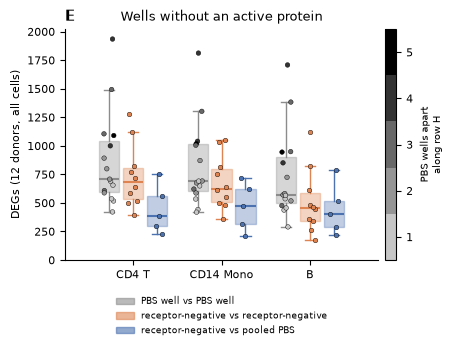

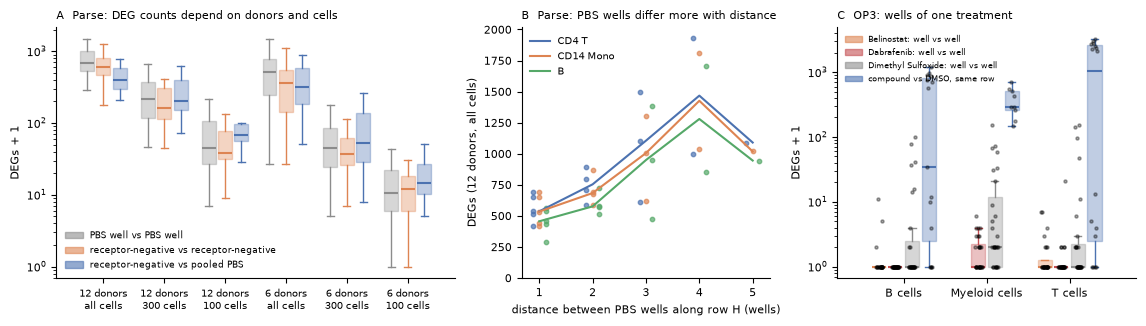

In [15]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

OP3_DEG_FILE = "cache/op3_posctrl/deg_ctrl_wells.csv"   # written by op3_positive_controls.ipynb
GREY, ORANGE, BLUE, RED = "#8C8C8C", "#DD8452", "#4C72B0", "#C44E52"
KINDS = [("PBS_vs_PBS", GREY, "PBS well vs PBS well"),
         ("inert_vs_inert", ORANGE, "receptor-negative vs receptor-negative"),
         ("inert_vs_PBS", BLUE, "receptor-negative vs pooled PBS")]
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.dpi": 300, "savefig.bbox": "tight"})
num = lambda s: int(re.search(r"(\d+)$", s).group(1))
jit = np.random.default_rng(0)

def box(ax, data, x, col, w):
    ax.boxplot([data if len(data) else [np.nan]], positions=[x], widths=w, patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=col, alpha=0.35, edgecolor=col), medianprops=dict(color=col, lw=1.5),
               whiskerprops=dict(color=col), capprops=dict(color=col))

D = R.copy()
D["dist"] = np.nan
pbs = D.kind == "PBS_vs_PBS"
D.loc[pbs, "dist"] = (D.loc[pbs, "cond_a"].map(num) - D.loc[pbs, "cond_b"].map(num)).abs()
FULL = D[(D.n_donors_set == 12) & (D.cap.astype(str) == "all")]

# ---------- Figure 4E: wells without an active protein ----------
fig, ax = plt.subplots(figsize=(4.3, 3.0))
w = 0.27
for j, ct in enumerate(TEST_CELL_TYPES):
    for k, (kind, col, _) in enumerate(KINDS):
        d = FULL[(FULL.ct == ct) & (FULL.kind == kind)]
        x = j + (k - 1) * w
        box(ax, d.n_deg.to_numpy(), x, col, w * 0.85)
        xs = x + jit.uniform(-w * 0.22, w * 0.22, len(d))
        if kind == "PBS_vs_PBS":
            sc = ax.scatter(xs, d.n_deg, c=d.dist, cmap="Greys", vmin=-1, vmax=5, s=11,
                            edgecolor="k", linewidth=0.3, zorder=3)
        else:
            ax.scatter(xs, d.n_deg, color=col, s=11, edgecolor="k", linewidth=0.3, zorder=3)
ax.set_xticks(range(len(TEST_CELL_TYPES)))
ax.set_xticklabels(TEST_CELL_TYPES)
ax.set_ylabel("DEGs (12 donors, all cells)")
ax.set_ylim(0, None)
cb = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, boundaries=np.arange(0.5, 5.6), ticks=[1, 2, 3, 4, 5])
cb.set_label("PBS wells apart\nalong row H", fontsize=7)
ax.legend([Patch(color=c, alpha=0.6) for _, c, _ in KINDS], [l for _, _, l in KINDS],
          fontsize=6.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
#ax.set_title("E", loc="left", fontweight="bold")
ax.set_title("E", loc="left", fontweight="bold", fontsize=11)
ax.set_title("Wells without an active protein", loc="center")
fig.savefig(os.path.join(RESULTS_DIR, "Fig4E_identical_wells.png"))
fig.savefig(os.path.join(RESULTS_DIR, "Fig4E_identical_wells.pdf"))
plt.show()

# ---------- Figure S3 ----------
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.3), gridspec_kw={"width_ratios": [1.6, 1, 1.2]})

# (A) power
D["power"] = np.where(D.n_donors_set == 12, "12 donors", "6 donors") + "\n" + D.cap.astype(str) + " cells"
order = [f"{n} donors\n{c} cells" for n in (12, 6) for c in ("all", 300, 100)]
for j, p in enumerate(order):
    for k, (kind, col, _) in enumerate(KINDS):
        box(ax[0], D[(D.power == p) & (D.kind == kind)].n_deg.to_numpy() + 1, j + (k - 1) * w, col, w * 0.85)
ax[0].set_yscale("log")
ax[0].set_xticks(range(len(order)))
ax[0].set_xticklabels(order, fontsize=7)
ax[0].set_ylabel("DEGs + 1")
ax[0].legend([Patch(color=c, alpha=0.6) for _, c, _ in KINDS], [l for _, _, l in KINDS],
             fontsize=6.5, frameon=False, loc="lower left")
ax[0].set_title("A  Parse: DEG counts depend on donors and cells", loc="left", fontsize=8)

# (B) distance along row H
CT_COL = dict(zip(TEST_CELL_TYPES, ["#4C72B0", "#DD8452", "#55A868"]))
P = FULL[FULL.kind == "PBS_vs_PBS"]
for k, ct in enumerate(TEST_CELL_TYPES):
    q = P[P.ct == ct]
    ax[1].scatter(q.dist + (k - 1) * 0.12, q.n_deg, s=10, color=CT_COL[ct], alpha=0.7)
    m = q.groupby("dist").n_deg.median()
    ax[1].plot(m.index, m.values, color=CT_COL[ct], label=ct)
ax[1].set_xticks(range(1, 6))
ax[1].set_xlabel("distance between PBS wells along row H (wells)")
ax[1].set_ylabel("DEGs (12 donors, all cells)")
ax[1].set_ylim(0, None)
ax[1].legend(fontsize=7, frameon=False)
ax[1].set_title("B  Parse: PBS wells differ more with distance", loc="left", fontsize=8)

# (C) OP3: wells of one treatment
if os.path.exists(OP3_DEG_FILE):
    O = pd.read_csv(OP3_DEG_FILE)
    conds = list(dict.fromkeys(O[O.kind == "same_treatment"].cond))
    dmso = [c for c in conds if re.search("(?i)sulfoxide|dmso", c)][0]
    conds = [c for c in conds if c != dmso] + [dmso]
    ccol = dict(zip(conds, [ORANGE, RED, GREY]))
    cts = sorted(O.ct.unique())
    groups = [(("same_treatment", c), ccol[c], f"{c}: well vs well") for c in conds] + \
             [(("vs_DMSO", None), BLUE, "compound vs DMSO, same row")]
    w3 = 0.8 / len(groups)
    for j, ct in enumerate(cts):
        for k, ((kind, c), col, _) in enumerate(groups):
            q = O[(O.ct == ct) & (O.kind == kind) & ((O.cond == c) if c else True)]
            x = j + (k - (len(groups) - 1) / 2) * w3
            box(ax[2], q.n_deg.to_numpy() + 1, x, col, w3 * 0.85)
            ax[2].scatter(x + jit.uniform(-w3 * 0.2, w3 * 0.2, len(q)), q.n_deg + 1, s=5, color="k", alpha=0.35, zorder=3)
    ax[2].set_yscale("log")
    ax[2].set_xticks(range(len(cts)))
    ax[2].set_xticklabels(cts)
    ax[2].set_ylabel("DEGs + 1")
    ax[2].legend([Patch(color=c, alpha=0.6) for _, c, _ in groups], [l for _, _, l in groups],
                 fontsize=6, frameon=False, loc="upper left")
    ax[2].set_title("C  OP3: wells of one treatment", loc="left", fontsize=8)
else:
    ax[2].text(0.5, 0.5, f"{OP3_DEG_FILE}\nnot found", ha="center", transform=ax[2].transAxes)

fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "FigS3_deg_power_distance.png"))
fig.savefig(os.path.join(RESULTS_DIR, "FigS3_deg_power_distance.pdf"))
plt.show()

In [16]:
# Effect size of the DEG floor. Add as a new cell at the end of parse_deg_power_check.ipynb
# (uses pseudobulk, EXPR_MASK, GENES, meta, DONORS, PBS_WELLS, STRICT_INERT, TEST_CELL_TYPES,
#  MIN_DONORS, N_CPUS, DEG_PADJ, RESULTS_DIR from the notebook).
# Runs only the full-power setting (12 donors, all cells): about 90 + 3 x len(STRONG) DESeq2 runs.
import itertools, os
import numpy as np
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# strong immune cytokines for comparison; edit the names to match meta.cond
STRONG = ["IFN-beta", "IL-2", "IL-15", "IFN-gamma", "IL-4"]
STRONG = [c for c in STRONG if c in set(meta.cond)]
print("strong cytokines found:", STRONG)
if len(STRONG) < 3:
    print("edit STRONG; some condition names:", sorted(meta.cond.unique())[:40])

LFC_CUTS = [0.25, 0.5, 1.0]
F_ES = os.path.join(RESULTS_DIR, "deg_effect_size_cpm10.csv")

def deg_table(ct, cond_a, cond_b):
    A, da = pseudobulk(ct, cond_a, DONORS, None)
    B, db = pseudobulk(ct, cond_b, DONORS, None)
    common = [d for d in da if d in db]
    if len(common) < MIN_DONORS:
        return None
    A = A[[da.index(d) for d in common]]
    B = B[[db.index(d) for d in common]]
    counts = np.vstack([A, B]).round().astype(np.int64)
    keep = EXPR_MASK[ct]
    names = [f"a{i}" for i in range(len(common))] + [f"b{i}" for i in range(len(common))]
    md_ = pd.DataFrame({"donor": [f"d{i}" for i in range(len(common))] * 2,
                        "condition": ["a"] * len(common) + ["b"] * len(common)}, index=names)
    dds = DeseqDataSet(counts=pd.DataFrame(counts[:, keep], index=names, columns=GENES[keep]),
                       metadata=md_, design="~donor + condition", quiet=True, n_cpus=N_CPUS)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "b", "a"], quiet=True, n_cpus=N_CPUS)
    st.summary()
    return st.results_df

COMPS = ([("PBS_vs_PBS", a, b) for a, b in itertools.combinations(PBS_WELLS, 2)] +
         [("inert_vs_inert", a, b) for a, b in itertools.combinations(STRICT_INERT, 2)] +
         [("inert_vs_PBS", "PBS_pooled", p) for p in STRICT_INERT] +
         [("strong_vs_PBS", "PBS_pooled", c) for c in STRONG])

done = set(pd.read_csv(F_ES)["key"]) if os.path.exists(F_ES) else set()
for ct in TEST_CELL_TYPES:
    for kind, ca, cb in COMPS:
        key = f"{ct}|{kind}|{ca}|{cb}"
        if key in done:
            continue
        r = deg_table(ct, ca, cb)
        if r is None:
            continue
        sig = r[r.padj < DEG_PADJ]
        row = dict(key=key, ct=ct, kind=kind, cond_a=ca, cond_b=cb)
        for c in LFC_CUTS:
            row[f"n_lfc_{c}"] = int((sig.log2FoldChange.abs() > c).sum())
        deg = sig[sig.log2FoldChange.abs() > LFC_CUTS[0]]
        row["median_abs_lfc"] = float(deg.log2FoldChange.abs().median()) if len(deg) else np.nan
        pd.DataFrame([row]).to_csv(F_ES, mode="a", header=not os.path.exists(F_ES), index=False)
        done.add(key)

E = pd.read_csv(F_ES)
cols = [f"n_lfc_{c}" for c in LFC_CUTS] + ["median_abs_lfc"]
print("Median over pairs and cell types (12 donors, all cells)")
print(E.groupby("kind")[cols].median().round(2))
print()
print(E.groupby(["ct", "kind"])[cols].median().round(2))

strong cytokines found: []
edit STRONG; some condition names: ['EGF', 'EPO', 'Megalin', 'PBS_H10', 'PBS_H11', 'PBS_H12', 'PBS_H7', 'PBS_H8', 'PBS_H9', 'PSPN', 'TPO']
Median over pairs and cell types (12 donors, all cells)
                n_lfc_0.25  n_lfc_0.5  n_lfc_1.0  median_abs_lfc
kind                                                            
PBS_vs_PBS           690.0      112.0       12.0            0.35
inert_vs_PBS         399.0       50.0        7.0            0.33
inert_vs_inert       596.5       90.0        9.5            0.33
strong_vs_PBS       3355.0     1346.0      349.0            0.43

                          n_lfc_0.25  n_lfc_0.5  n_lfc_1.0  median_abs_lfc
ct        kind                                                            
B         PBS_vs_PBS           570.0      121.0       12.0            0.37
          inert_vs_PBS         399.0       44.0        6.0            0.33
          inert_vs_inert       455.0       94.0       12.0            0.37
          st

In [17]:
# Effect size of DEGs for strong immune cytokines, as a reference for the DEG floor.
# Add as a new cell AFTER deg_effect_size_cell.py in parse_deg_power_check.ipynb
# (uses H5/MAT/INDPTR, CODES, CT_MAP, aggregate, pseudobulk, EXPR_MASK, GENES, DONORS,
#  TEST_CELL_TYPES, MIN_CELLS_DEG, MIN_DONORS, N_CPUS, DEG_PADJ, PWR_DIR, RESULTS_DIR,
#  deg_table's imports and F_ES / LFC_CUTS from the previous cell).
# Cost: one extra pass over the counts (like section 2) + 15 DESeq2 runs.
import os, re
import numpy as np
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# 1. strong cytokines: match names in the cytokine column (check the printout)
PATTERNS = [r"(?i)^IFN[-_ ]?(b|beta)", r"(?i)^IFN[-_ ]?(g|gamma)", r"(?i)^IL[-_ ]?2$",
            r"(?i)^IL[-_ ]?15$", r"(?i)^IL[-_ ]?4$"]
cyt_codes, cyt_cats = CODES["cytokine"]
don_codes, don_cats = CODES["donor"]
ct_codes, ct_cats = CODES["cell_type"]
STRONG = [c for p in PATTERNS for c in cyt_cats if re.search(p, c)]
print("strong cytokines:", STRONG)
assert STRONG, "no match; set STRONG by hand from: " + ", ".join(cyt_cats[:100])

# 2. pseudobulk per donor x cytokine x cell type (all cells), cached
F_PB2 = os.path.join(PWR_DIR, "pb_strong.npz")
F_META2 = os.path.join(PWR_DIR, "pb_strong_meta.csv")
ct_main = np.array([CT_MAP.get(c) for c in ct_cats], dtype=object)
pos = np.flatnonzero(np.isin(cyt_cats, STRONG)[cyt_codes] & np.isin(ct_main, TEST_CELL_TYPES)[ct_codes])
s2 = pd.DataFrame({"donor": don_cats[don_codes[pos]], "cond": cyt_cats[cyt_codes[pos]],
                   "ct": ct_main[ct_codes[pos]]}, index=pos)
g2 = s2.groupby(["donor", "cond", "ct"], sort=True)
meta2 = g2.size().rename("n").reset_index()
print(f"{len(pos):,} cells, {len(meta2)} pseudobulks")
if os.path.exists(F_PB2) and os.path.exists(F_META2) and len(pd.read_csv(F_META2)) == len(meta2):
    PB2 = np.load(F_PB2)["pb"]
else:
    PB2 = aggregate(s2.index.to_numpy(), g2.ngroup().to_numpy(), len(meta2))
    np.savez_compressed(F_PB2, pb=PB2.astype(np.float32))
    meta2.to_csv(F_META2, index=False)

def pb_strong(ct, cond):
    m = meta2[(meta2.ct == ct) & (meta2.cond == cond) & (meta2.n >= MIN_CELLS_DEG)]
    return PB2[m.index], list(m.donor)

# 3. DESeq2: strong cytokine vs pooled PBS, same design, thresholds and gene filter
def deg_vs_pbs(ct, cond):
    A, da = pseudobulk(ct, "PBS_pooled", DONORS, None)
    B, db = pb_strong(ct, cond)
    common = [d for d in da if d in db]
    if len(common) < MIN_DONORS:
        return None
    A = A[[da.index(d) for d in common]]
    B = B[[db.index(d) for d in common]]
    counts = np.vstack([A, B]).round().astype(np.int64)
    keep = EXPR_MASK[ct]
    names = [f"a{i}" for i in range(len(common))] + [f"b{i}" for i in range(len(common))]
    md_ = pd.DataFrame({"donor": [f"d{i}" for i in range(len(common))] * 2,
                        "condition": ["a"] * len(common) + ["b"] * len(common)}, index=names)
    dds = DeseqDataSet(counts=pd.DataFrame(counts[:, keep], index=names, columns=GENES[keep]),
                       metadata=md_, design="~donor + condition", quiet=True, n_cpus=N_CPUS)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "b", "a"], quiet=True, n_cpus=N_CPUS)
    st.summary()
    return st.results_df

done = set(pd.read_csv(F_ES)["key"]) if os.path.exists(F_ES) else set()
for ct in TEST_CELL_TYPES:
    for c in STRONG:
        key = f"{ct}|strong_vs_PBS|PBS_pooled|{c}"
        if key in done:
            continue
        r = deg_vs_pbs(ct, c)
        if r is None:
            continue
        sig = r[r.padj < DEG_PADJ]
        row = dict(key=key, ct=ct, kind="strong_vs_PBS", cond_a="PBS_pooled", cond_b=c)
        for cut in LFC_CUTS:
            row[f"n_lfc_{cut}"] = int((sig.log2FoldChange.abs() > cut).sum())
        deg = sig[sig.log2FoldChange.abs() > LFC_CUTS[0]]
        row["median_abs_lfc"] = float(deg.log2FoldChange.abs().median()) if len(deg) else np.nan
        pd.DataFrame([row]).to_csv(F_ES, mode="a", header=not os.path.exists(F_ES), index=False)
        done.add(key)

E = pd.read_csv(F_ES)
cols = [f"n_lfc_{c}" for c in LFC_CUTS] + ["median_abs_lfc"]
print("Median over pairs and cell types (12 donors, all cells)")
print(E.groupby("kind")[cols].median().round(2))
print()
print(E[E.kind == "strong_vs_PBS"].pivot_table(index="cond_b", columns="ct", values=cols[:3]).round(0))


strong cytokines: [np.str_('IFN-beta'), np.str_('IFN-gamma'), np.str_('IL-2'), np.str_('IL-15'), np.str_('IL-4')]
366,749 cells, 180 pseudobulks
Median over pairs and cell types (12 donors, all cells)
                n_lfc_0.25  n_lfc_0.5  n_lfc_1.0  median_abs_lfc
kind                                                            
PBS_vs_PBS           690.0      112.0       12.0            0.35
inert_vs_PBS         399.0       50.0        7.0            0.33
inert_vs_inert       596.5       90.0        9.5            0.33
strong_vs_PBS       3355.0     1346.0      349.0            0.43

          n_lfc_0.25                   n_lfc_0.5                   n_lfc_1.0  \
ct                 B CD14 Mono   CD4 T         B CD14 Mono   CD4 T         B   
cond_b                                                                         
IFN-beta      3993.0    5660.0  3528.0    1571.0    3625.0  1474.0     382.0   
IFN-gamma     1861.0    3396.0  2064.0     495.0    1703.0   617.0      78.0   
IL-15   

## 7. Figure 4 with panel E (A–D kept as 2 × 2, E as a full-width row)

figures/Fig4_audits_2x2.png: 3284 x 2386
figures/Fig4_audits.png: 3284 x 2386
using: figures/Fig4_audits.png
saved: figures/Fig4_audits_with_e.png


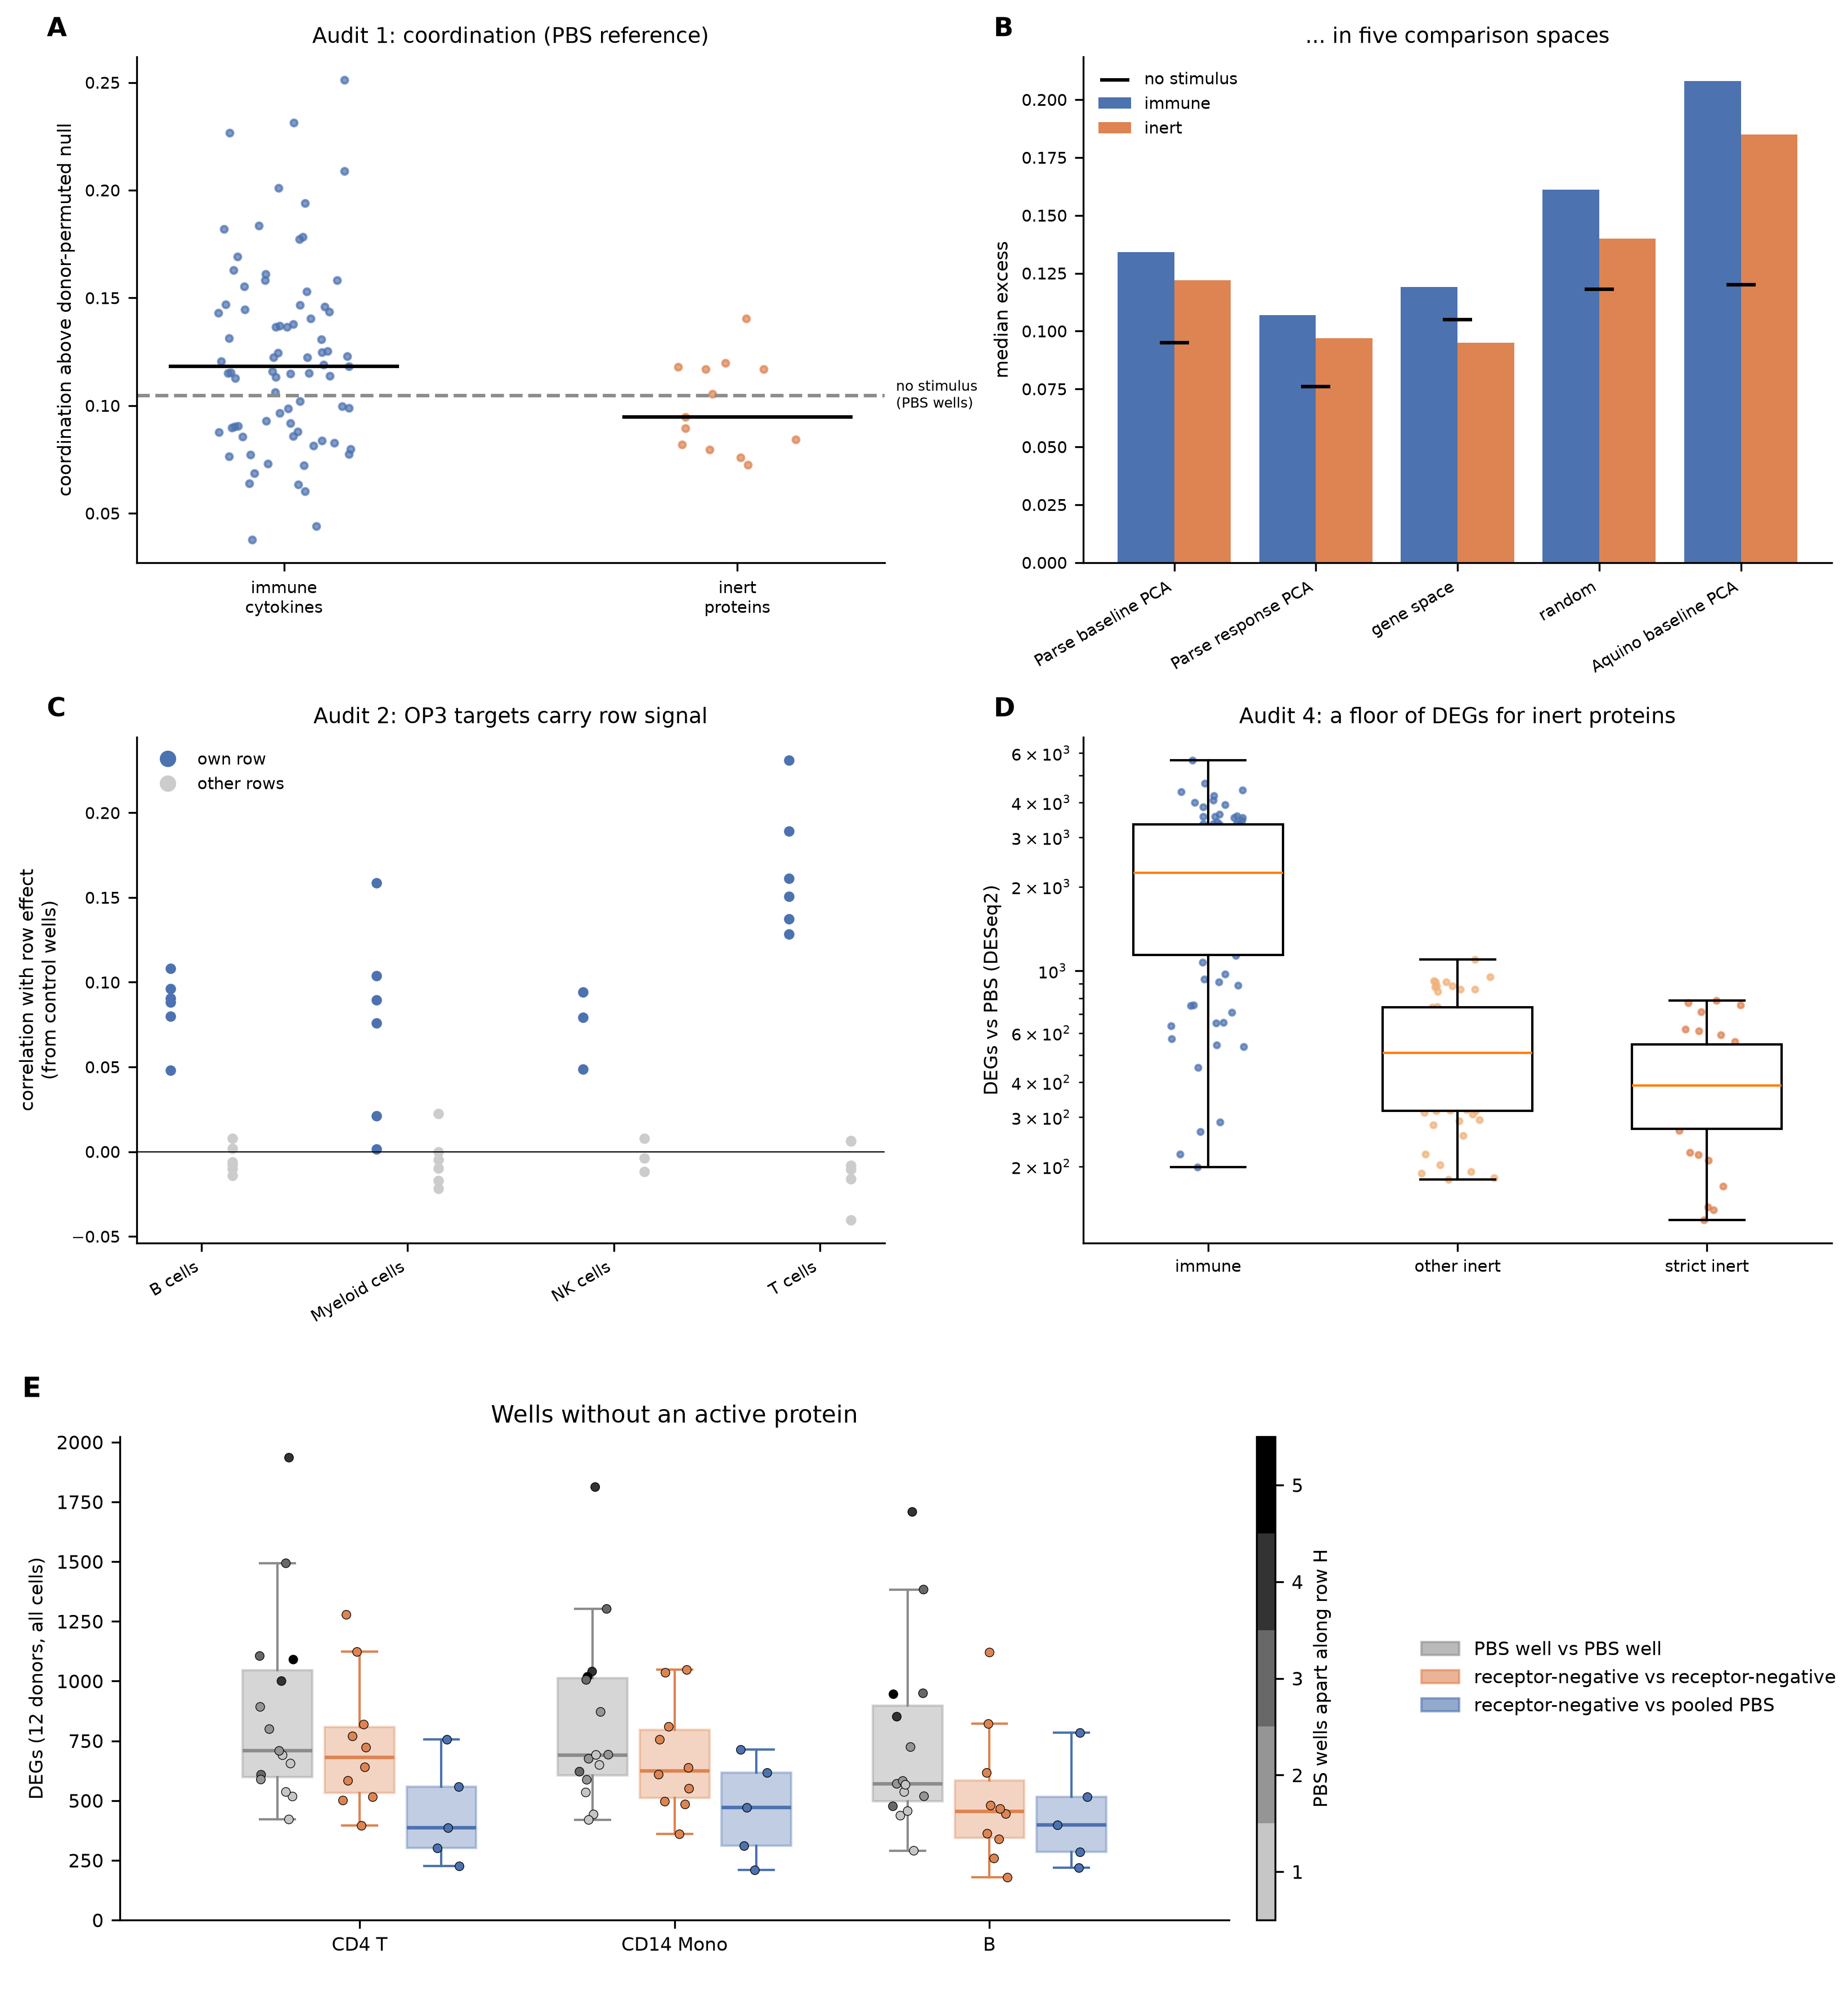

In [19]:
# Figure 4 with panel E: keeps A-D as a 2 x 2 grid and adds E as a full-width row below,
# drawn at the same scale and font size as A-D. Run in parse_deg_power_check.ipynb after section 4
# (uses R and TEST_CELL_TYPES).
import glob, os, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

# 1. find the 2 x 2 version of Figure 4 (not the old one-row version)
cands = [p for p in glob.glob("**/Fig4_audits*.png", recursive=True)
         if ".ipynb_checkpoints" not in p and "with_e" not in p]
for p in cands:
    im = Image.open(p)
    print(f"{p}: {im.width} x {im.height}")
grid = [p for p in cands if Image.open(p).width / Image.open(p).height < 2.5]
assert grid, "no 2 x 2 Figure 4 found; set TOP_PATH by hand"
TOP_PATH = max(grid, key=os.path.getmtime)
print("using:", TOP_PATH)
top = Image.open(TOP_PATH).convert("RGB")
dpi = top.info.get("dpi", (200, 200))[0]
dpi = dpi if dpi and dpi > 50 else 200

# 2. draw E as a full-width row, half the height of the 2 x 2 block, default font sizes
GREY, ORANGE, BLUE = "#8C8C8C", "#DD8452", "#4C72B0"
KINDS = [("PBS_vs_PBS", GREY, "PBS well vs PBS well"),
         ("inert_vs_inert", ORANGE, "receptor-negative vs receptor-negative"),
         ("inert_vs_PBS", BLUE, "receptor-negative vs pooled PBS")]
num = lambda s: int(re.search(r"(\d+)$", s).group(1))
F = R[(R.n_donors_set == 12) & (R.cap.astype(str) == "all")].copy()
pbs = F.kind == "PBS_vs_PBS"
F["dist"] = np.nan
F.loc[pbs, "dist"] = (F.loc[pbs, "cond_a"].map(num) - F.loc[pbs, "cond_b"].map(num)).abs()

plt.rcdefaults()
plt.rcParams.update({"font.size": 8, "axes.titlesize": 10, "axes.labelsize": 8, "legend.fontsize": 8})
fig = plt.figure(figsize=(top.width / dpi, top.height / 2 / dpi), dpi=dpi)
ax = fig.add_axes([0.065, 0.14, 0.60, 0.72])          # left part of the row, aligned with A and C
rng = np.random.default_rng(0)
w = 0.26
for j, ct in enumerate(TEST_CELL_TYPES):
    for k, (kind, col, _) in enumerate(KINDS):
        d = F[(F.ct == ct) & (F.kind == kind)]
        x = j + (k - 1) * w
        ax.boxplot([d.n_deg], positions=[x], widths=w * 0.85, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=col, alpha=0.35, edgecolor=col), medianprops=dict(color=col, lw=1.5),
                   whiskerprops=dict(color=col), capprops=dict(color=col))
        xs = x + rng.uniform(-w * 0.22, w * 0.22, len(d))
        if kind == "PBS_vs_PBS":
            sc = ax.scatter(xs, d.n_deg, c=d.dist, cmap="Greys", vmin=-1, vmax=5, s=14,
                            edgecolor="k", linewidth=0.3, zorder=3)
        else:
            ax.scatter(xs, d.n_deg, color=col, s=14, edgecolor="k", linewidth=0.3, zorder=3)
ax.set_xticks(range(len(TEST_CELL_TYPES)))
ax.set_xticklabels(TEST_CELL_TYPES)
ax.set_ylabel("DEGs (12 donors, all cells)")
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Wells without an active protein")
fig.text(0.012, 0.93, "E", fontsize=12, fontweight="bold", va="center")
cax = fig.add_axes([0.68, 0.14, 0.010, 0.72])
cb = fig.colorbar(sc, cax=cax, boundaries=np.arange(0.5, 5.6), ticks=[1, 2, 3, 4, 5])
cb.set_label("PBS wells apart along row H")
fig.legend([Patch(color=c, alpha=0.6) for _, c, _ in KINDS], [l for _, _, l in KINDS],
           frameon=False, loc="center left", bbox_to_anchor=(0.76, 0.5))
E_PATH = os.path.join(os.path.dirname(TOP_PATH), "Fig4E_row.png")
fig.savefig(E_PATH, dpi=dpi)
plt.close(fig)

# 3. stack: 2 x 2 block on top, E row below
e = Image.open(E_PATH).convert("RGB").resize((top.width, top.height // 2))
out = Image.new("RGB", (top.width, top.height + e.height), "white")
out.paste(top, (0, 0))
out.paste(e, (0, top.height))
OUT_PATH = os.path.join(os.path.dirname(TOP_PATH), "Fig4_audits_with_e.png")
out.save(OUT_PATH, dpi=(dpi, dpi))
print("saved:", OUT_PATH)
display(out)